<a href="https://colab.research.google.com/github/trinhkimngan1602/BaitapAI01/blob/main/fr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
import cv2
import numpy as np
from google.colab import drive
from PIL import Image
from pillow_heif import register_heif_opener

# 1. Kết nối Drive và chuẩn bị đọc file HEIC
register_heif_opener()
drive.mount('/content/drive')

# 2. Đường dẫn (Hãy đảm bảo folder 'Raw' chứa 7 thư mục con của 7 người)
RAW_PATH = '/content/drive/MyDrive/AnhF8'
PROCESSED_PATH = '/content/dataset_200x200'

# 3. Sử dụng bộ nhận diện khuôn mặt có sẵn của OpenCV
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def process_images():
    if not os.path.exists(PROCESSED_PATH):
        os.makedirs(PROCESSED_PATH)

    # Lấy danh sách thư mục của các thành viên
    people = [d for d in os.listdir(RAW_PATH) if os.path.isdir(os.path.join(RAW_PATH, d))]

    for person_name in people:
        person_raw_path = os.path.join(RAW_PATH, person_name)
        person_save_path = os.path.join(PROCESSED_PATH, person_name)

        if not os.path.exists(person_save_path): os.makedirs(person_save_path)

        print(f"--- Đang xử lý: {person_name} ---")
        count = 0

        for img_name in os.listdir(person_raw_path):
            img_path = os.path.join(person_raw_path, img_name)
            try:
                # Đọc ảnh (Hỗ trợ HEIC, JPG, PNG)
                img_pil = Image.open(img_path).convert('RGB')
                img_np = np.array(img_pil)
                gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY) # Chuyển xám để nhận diện nhanh hơn

                # Nhận diện khuôn mặt
                faces = face_cascade.detectMultiScale(gray, 1.1, 4)

                for (x, y, w, h) in faces:
                    # Cắt khuôn mặt
                    face = img_np[y:y+h, x:x+w]
                    # Resize về 200x200 theo đúng đề bài
                    face_resized = cv2.resize(face, (200, 200))
                    # Chuyển về định dạng BGR để lưu bằng OpenCV
                    face_save = cv2.cvtColor(face_resized, cv2.COLOR_RGB2BGR)

                    cv2.imwrite(os.path.join(person_save_path, f"{person_name}_{count}.jpg"), face_save)
                    count += 1
                    break # Chỉ lấy 1 khuôn mặt rõ nhất mỗi ảnh

            except Exception as e:
                continue # Bỏ qua ảnh lỗi

        print(f"Hoàn thành: {count} ảnh khuôn mặt.")

process_images()
print("\n===> XỬ LÝ XONG! Giờ bạn hãy sang Phần 2 (Training).")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Đang xử lý: Anh Thư ---
Hoàn thành: 57 ảnh khuôn mặt.
--- Đang xử lý: Quế Phượng ---
Hoàn thành: 33 ảnh khuôn mặt.
--- Đang xử lý: Ngô Quỳnh Anh ---
Hoàn thành: 46 ảnh khuôn mặt.
--- Đang xử lý: Lương Thị Như Bình ---
Hoàn thành: 60 ảnh khuôn mặt.
--- Đang xử lý: Trịnh Thị Kim Ngân ---
Hoàn thành: 50 ảnh khuôn mặt.
--- Đang xử lý: Nguyễn Hoàng Long ---
Hoàn thành: 58 ảnh khuôn mặt.
--- Đang xử lý: Đào Ngọc Thi ---
Hoàn thành: 139 ảnh khuôn mặt.

===> XỬ LÝ XONG! Giờ bạn hãy sang Phần 2 (Training).


Found 447 images belonging to 7 classes.
Found 109 images belonging to 7 classes.
Danh sách lớp học được: ['Anh Thư', 'Lương Thị Như Bình', 'Ngô Quỳnh Anh', 'Nguyễn Hoàng Long', 'Quế Phượng', 'Trịnh Thị Kim Ngân', 'Đào Ngọc Thi']

--- Đang bắt đầu huấn luyện... Vui lòng đợi ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.3669 - loss: 1.8504 - val_accuracy: 0.4312 - val_loss: 1.5867
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 519ms/step - accuracy: 0.5369 - loss: 1.3796 - val_accuracy: 0.4954 - val_loss: 1.3488
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 381ms/step - accuracy: 0.5928 - loss: 1.1709 - val_accuracy: 0.5046 - val_loss: 1.3082
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 523ms/step - accuracy: 0.6085 - loss: 1.1295 - val_accuracy: 0.5963 - val_loss: 1.2732
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 383ms/step - accuracy: 0.6421 - loss: 1.0701 - val_accuracy: 0.5229 - val_loss: 1.2588
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 447ms/step - accuracy: 0.6577 - loss: 1.0053 - val_accuracy: 0.6330 - val_loss: 1.1667
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 370ms/step - accuracy: 0.6622 - loss: 0.9911 - val_accuracy: 0.6422 - val_loss: 1.1234
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 499ms/step - accuracy: 0.6890 - loss: 0.9754 - val_accuracy: 0.53


===> HUẤN LUYỆN XONG VÀ ĐÃ LƯU MODEL!


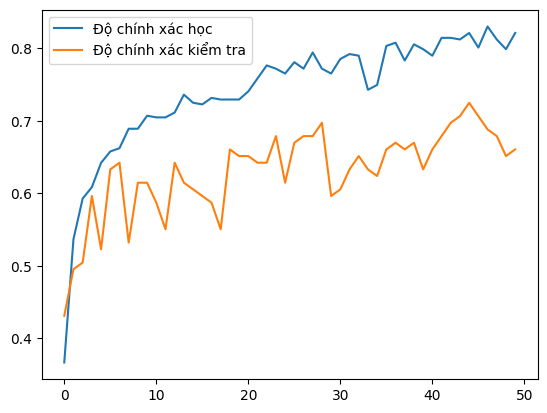

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. Cấu hình các thông số
IMG_SIZE = (200, 200) # Theo yêu cầu đề bài
BATCH_SIZE = 32
EPOCHS = 50 # Số lần lặp lại việc học

# 2. Chuẩn bị dữ liệu và Tăng cường (Data Augmentation)
# Chúng ta chia 80% ảnh để học (train) và 20% để kiểm tra (validation)
datagen = ImageDataGenerator(
    rescale=1./255,           # Đưa giá trị pixel về đoạn [0, 1]
    rotation_range=20,        # Xoay ảnh ngẫu nhiên 20 độ
    width_shift_range=0.2,    # Dịch chuyển ngang
    height_shift_range=0.2,   # Dịch chuyển dọc
    shear_range=0.2,          # Làm biến dạng ảnh
    zoom_range=0.2,           # Phóng to/thu nhỏ
    horizontal_flip=True,     # Lật ảnh ngang
    fill_mode='nearest',
    validation_split=0.2       # Chia 20% dữ liệu để test
)

train_generator = datagen.flow_from_directory(
    '/content/dataset_200x200', # Thư mục ảnh đã xử lý ở phần 1
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    '/content/dataset_200x200',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# In ra danh sách tên 7 người mà máy đã học được
class_names = list(train_generator.class_indices.keys())
print("Danh sách lớp học được:", class_names)

# 3. Xây dựng cấu trúc mạng CNN
model = Sequential([
    # Lớp lọc 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    MaxPooling2D(2, 2),

    # Lớp lọc 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Lớp lọc 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Chuyển về mảng 1 chiều và đưa vào các lớp học sâu
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5), # Chống học vẹt
    Dense(7, activation='softmax') # Đầu ra là 7 người
])

# 4. Biên dịch mô hình
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Bắt đầu huấn luyện
print("\n--- Đang bắt đầu huấn luyện... Vui lòng đợi ---")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    verbose=1
)

# 6. Lưu mô hình lại để dùng cho phần 3
model.save('face_model_200x200.h5')
print("\n===> HUẤN LUYỆN XONG VÀ ĐÃ LƯU MODEL!")

# 7. Vẽ biểu đồ độ chính xác (tùy chọn để xem kết quả)
plt.plot(history.history['accuracy'], label='Độ chính xác học')
plt.plot(history.history['val_accuracy'], label='Độ chính xác kiểm tra')
plt.legend()
plt.show()

Thứ tự các lớp (classes): ['Anh Thư', 'Lương Thị Như Bình', 'Ngô Quỳnh Anh', 'Nguyễn Hoàng Long', 'Quế Phượng', 'Trịnh Thị Kim Ngân', 'Đào Ngọc Thi']

--- CHỌN ẢNH ĐỂ KIỂM TRA ---
1. Tải ảnh từ máy tính lên
2. Lấy ảnh ngẫu nhiên từ tập dữ liệu (Dùng để chụp ảnh báo cáo)
Nhập 1 hoặc 2: 1


Saving anh6.jpg to anh6 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step


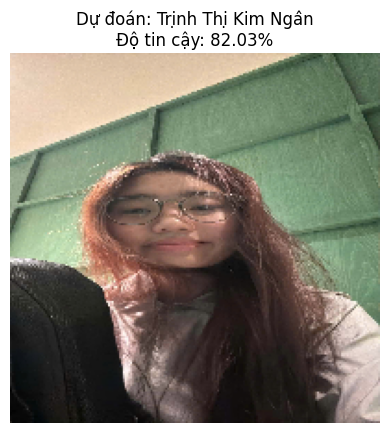

In [14]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from google.colab import files
import os

# 1. Tải mô hình đã lưu
model = load_model('face_model_200x200.h5')

# 2. Lấy danh sách tên 7 người từ thư mục (để hiển thị nhãn)
data_path = '/content/dataset_200x200'
class_names = sorted(os.listdir(data_path))
print("Thứ tự các lớp (classes):", class_names)

def predict_and_show(img_path):
    # Đọc và tiền xử lý ảnh
    img = image.load_img(img_path, target_size=(200, 200))
    img_tensor = image.img_to_array(img)
    img_tensor = np.expand_dims(img_tensor, axis=0)
    img_tensor /= 255.0  # Chuẩn hóa giống lúc train

    # Dự đoán
    prediction = model.predict(img_tensor)
    idx = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    # Hiển thị
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Dự đoán: {class_names[idx]}\nĐộ tin cậy: {confidence:.2f}%")
    plt.show()

# --- CHỌN CÁCH ĐỂ TEST ---

print("\n--- CHỌN ẢNH ĐỂ KIỂM TRA ---")
print("1. Tải ảnh từ máy tính lên")
print("2. Lấy ảnh ngẫu nhiên từ tập dữ liệu (Dùng để chụp ảnh báo cáo)")

choice = input("Nhập 1 hoặc 2: ")

if choice == '1':
    uploaded = files.upload()
    for fn in uploaded.keys():
        predict_and_show(fn)
else:
    # Lấy đại 1 ảnh trong thư mục Validation để test
    import random
    random_person = random.choice(class_names)
    random_img = random.choice(os.listdir(os.path.join(data_path, random_person)))
    test_path = os.path.join(data_path, random_person, random_img)
    print(f"Đang test với ảnh của: {random_person}")
    predict_and_show(test_path)